### Walmart Weekly Sales Prediction using Machine Learning

#### Import Libraries

In [563]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Data Collection and Cleaning

In [564]:
df=pd.read_csv('Walmart_Sales.csv')
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


In [565]:
df.shape

(6435, 8)

In [566]:
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

In [567]:
df.columns=df.columns.str.strip()
df.columns=df.columns.str.lower()

In [568]:
df.columns

Index(['store', 'date', 'weekly_sales', 'holiday_flag', 'temperature',
       'fuel_price', 'cpi', 'unemployment'],
      dtype='object')

In [569]:
df.head()

,store,date,weekly_sales,holiday_flag,temperature,fuel_price,cpi,unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [570]:
df.isnull().sum()

store           0
date            0
weekly_sales    0
holiday_flag    0
temperature     0
fuel_price      0
cpi             0
unemployment    0
dtype: int64

there are no missing values

In [571]:
df.duplicated().sum()

np.int64(0)

no duplicates

In [572]:
df.describe()

,store,weekly_sales,holiday_flag,temperature,fuel_price,cpi,unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [573]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   store         6435 non-null   int64  
 1   date          6435 non-null   object 
 2   weekly_sales  6435 non-null   float64
 3   holiday_flag  6435 non-null   int64  
 4   temperature   6435 non-null   float64
 5   fuel_price    6435 non-null   float64
 6   cpi           6435 non-null   float64
 7   unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [574]:
df['date']=pd.to_datetime(df['date'],format="%d-%m-%Y") # format is used to tell that my date column is in this format so it helps it to read the date column 

# and pandas returns date in this format YYYY-MM-DD  

In [575]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   store         6435 non-null   int64         
 1   date          6435 non-null   datetime64[ns]
 2   weekly_sales  6435 non-null   float64       
 3   holiday_flag  6435 non-null   int64         
 4   temperature   6435 non-null   float64       
 5   fuel_price    6435 non-null   float64       
 6   cpi           6435 non-null   float64       
 7   unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


#### Dataset Columns Explanation

| Column | Meaning |
|------|------|
| **store** | Store ID number. Example: `1` means Store number 1. |
| **date** | The week ending date for that sales record. |
| **weekly_sales** | Total sales of that store in that week (in dollars). |
| **holiday_flag** | Indicates whether that week had a holiday or not. `1 = Holiday week`, `0 = Normal week`. |
| **temperature** | Temperature of that location during that week. |
| **fuel_price** | Price of fuel (gas/petrol) at that time. |
| **cpi** | Consumer Price Index — shows the change in prices of goods and services over time (inflation indicator). |
| **unemployment** | Unemployment rate during that time. |


highest sale in week
holiday rha to avg sale kitna 
holidya nia to kitna
create temp group and based on it sales(measn temp sales ko affect kr rha kya)
in which month highest sales
fuel price ka bhi same temp
top 5 sales week

#### Exploratory Data Analysis

In [576]:
# sales by date
gb1=df.groupby('date')['weekly_sales'].sum().reset_index().sort_values(by='weekly_sales',ascending=False)
gb1

,date,weekly_sales
46,2010-12-24,80931415.60
98,2011-12-23,76998241.31
94,2011-11-25,66593605.26
42,2010-11-26,65821003.24
45,2010-12-17,61820799.85
...,...,...
49,2011-01-14,40673678.04
50,2011-01-21,40654648.03
47,2010-12-31,40432519.00
103,2012-01-27,39834974.67


In [577]:
# maximum sale in week
gb1[gb1['weekly_sales']==gb1['weekly_sales'].max()]

,date,weekly_sales
46,2010-12-24,80931415.6


The highest weekly sales occurred on 24 December 2010

In [578]:
# encoding

# 1-holiday yes
# 0- no

df['holiday_flag']=df['holiday_flag'].map({0:'no',1:'yes'})

In [579]:
# Average Weekly Sales by Holiday Flag
df.groupby('holiday_flag')['weekly_sales'].mean().reset_index()

,holiday_flag,weekly_sales
0,no,1.041256e+06
1,yes,1.122888e+06


The average weekly sales during holiday weeks (1,122,887) are higher than during non-holiday weeks (1,041,256).

In [580]:
df['temperature'].min() #min temp

np.float64(-2.06)

In [581]:
df['temperature'].max() #max temp

np.float64(100.14)

In [582]:
def temp_group(temp):
    if (temp>=-2.00 and temp<10.00):
        return "-2.00 to 10.00"
    elif(temp>=10.00 and temp<20.00):
        return "10.00 to 20.00"
    elif(temp>=20.00 and temp<30.00):
        return "20.00 to 30.00"
    elif(temp>=30.00 and temp<40.00):
        return "30.00 to 40.00"
    elif(temp>=40.00 and temp<50.00):
        return "40.00 to 50.00"
    elif(temp>=50.00 and temp<60.00):
        return "50.00 to 60.00"
    elif(temp>=60.00 and temp<70.00):
        return "60.00 to 70.00"
    elif(temp>=70.00 and temp<80.00):
        return "70.00 to 80.00"
    elif(temp>=80.00 and temp<90.00):
        return "80.00 to 90.00"
    else:
        return "90.00 to 100.15"

In [583]:
#create extra column temp_group 

df['temp_group']=df['temperature'].apply(temp_group) 

In [584]:
#sales by temp_group

df.groupby('temp_group')['weekly_sales'].sum().reset_index().sort_values(by='weekly_sales',ascending=False)

,temp_group,weekly_sales
7,70.00 to 80.00,1.292776e+09
6,60.00 to 70.00,1.292715e+09
5,50.00 to 60.00,1.122390e+09
4,40.00 to 50.00,9.640847e+08
8,80.00 to 90.00,8.515029e+08
3,30.00 to 40.00,6.491767e+08
2,20.00 to 30.00,3.475819e+08
9,90.00 to 100.15,1.448089e+08
1,10.00 to 20.00,6.787929e+07
0,-2.00 to 10.00,4.304461e+06


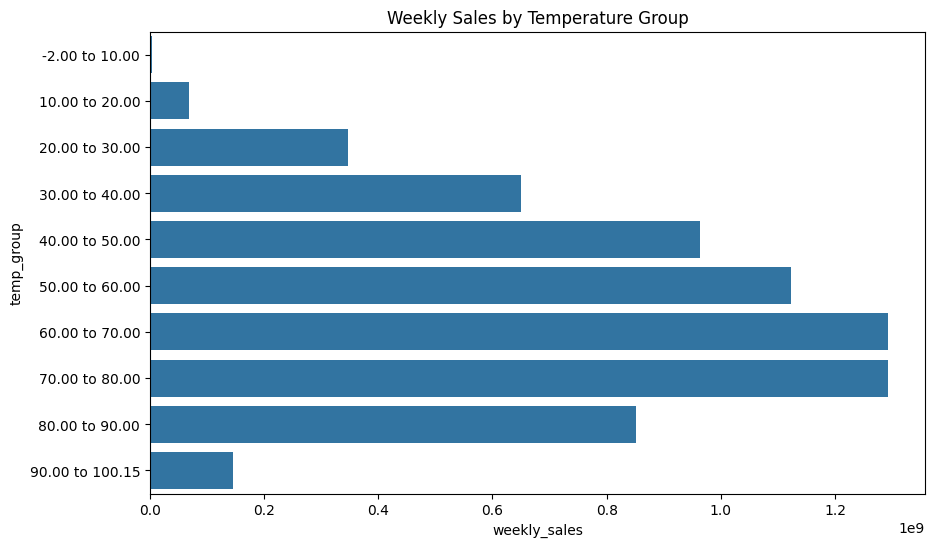

In [585]:
gb2=df.groupby('temp_group')['weekly_sales'].sum().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=gb2,x='weekly_sales',y='temp_group')
plt.title("Weekly Sales by Temperature Group")
plt.show()

moderate temperature group have highest sales

In [586]:
df['month']=df['date'].dt.month

In [587]:
df['month_name']=df['date'].dt.month_name()

   month_name  weekly_sales
5        July  6.500010e+08
0       April  6.468598e+08
6        June  6.226299e+08
1      August  6.130902e+08
7       March  5.927859e+08
10    October  5.847848e+08
11  September  5.787612e+08
2    December  5.768386e+08
3    February  5.687279e+08
8         May  5.571256e+08
9    November  4.130157e+08
4     January  3.325984e+08


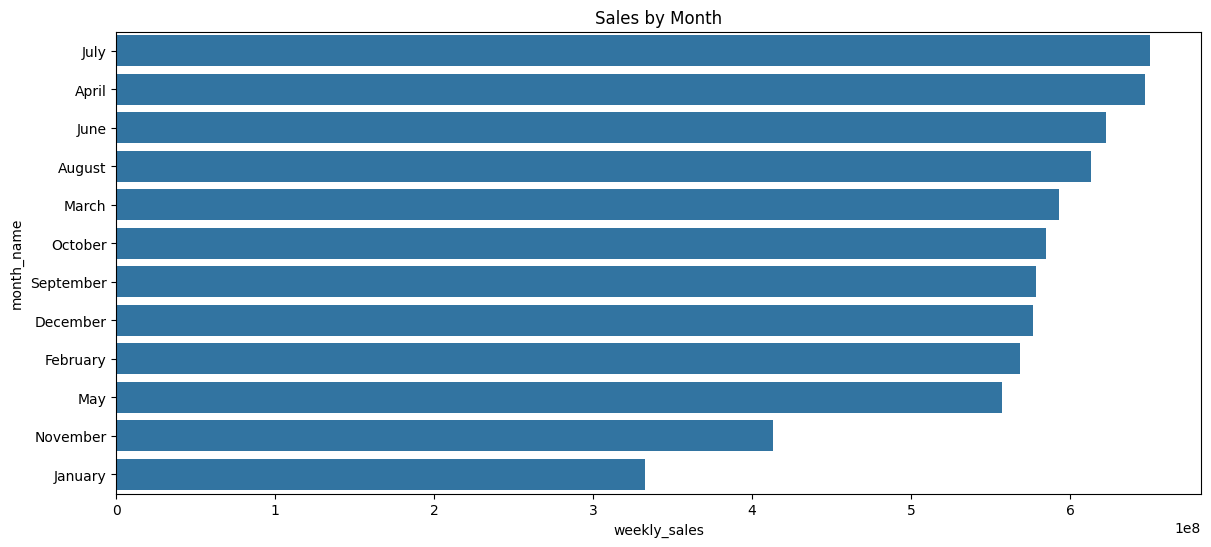

In [588]:
#sales by month

gb3=df.groupby('month_name')['weekly_sales'].sum().reset_index().sort_values(by='weekly_sales',ascending=False)
print(gb3)

plt.figure(figsize=(14,6))
sns.barplot(data=gb3,y='month_name',x='weekly_sales')
plt.title("Sales by Month")
plt.show()

In [589]:
gb3[gb3['weekly_sales']==gb3['weekly_sales'].max()] #highest sales

,month_name,weekly_sales
5,July,6.500010e+08


July recorded the highest total weekly sales (650,000,977.25)

In [590]:
df['fuel_price'].min()

np.float64(2.472)

In [591]:
df['fuel_price'].max()

np.float64(4.468)

In [592]:
def fuel_group(fuel):
    if fuel >= 2.4 and fuel < 2.8:
        return "2.4 to 2.8"
    elif fuel >= 2.8 and fuel < 3.2:
        return "2.8 to 3.2"
    elif fuel >= 3.2 and fuel < 3.6:
        return "3.2 to 3.6"
    elif fuel >= 3.6 and fuel < 4.0:
        return "3.6 to 4.0"
    else:
        return "4.0 to 4.5"

In [593]:
df['fuel_group']=df['fuel_price'].apply(fuel_group) #created another column fuel group

   fuel_group  weekly_sales
3  3.6 to 4.0  2.096095e+09
2  3.2 to 3.6  1.579357e+09
1  2.8 to 3.2  1.548170e+09
0  2.4 to 2.8  1.081888e+09
4  4.0 to 4.5  4.317094e+08


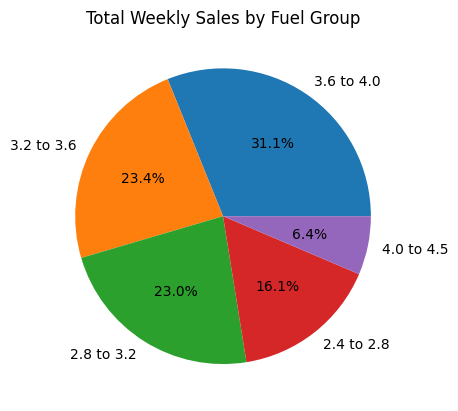

In [594]:
#sales by fuel group
gb7=df.groupby('fuel_group')['weekly_sales'].sum().reset_index().sort_values(by='weekly_sales',ascending=False)
print(gb7)

plt.pie(gb7['weekly_sales'],labels=gb7['fuel_group'],autopct="%1.1f%%")
plt.title("Total Weekly Sales by Fuel Group")
plt.show()

weekly sales are highest when the fuel price is between 3.6 and 4.0, generating approximately 2.09 billion in total sales

In [595]:
gb1.head(5)

,date,weekly_sales
46,2010-12-24,80931415.60
98,2011-12-23,76998241.31
94,2011-11-25,66593605.26
42,2010-11-26,65821003.24
45,2010-12-17,61820799.85


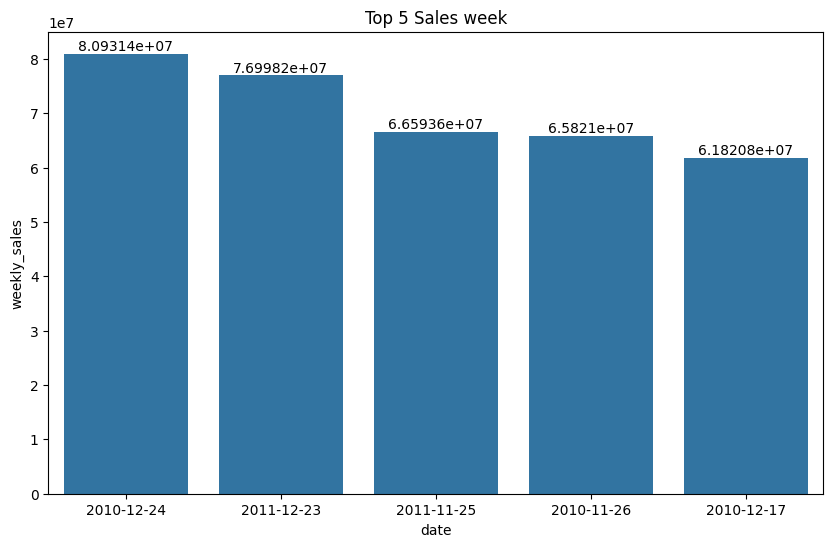

In [596]:
plt.figure(figsize=(10,6))
ax=sns.barplot(data=gb1.head(5),x='date',y='weekly_sales')
for bar in ax.containers:
    ax.bar_label(bar)

plt.title("Top 5 Sales week")
plt.show()


The highest weekly sales occurred on 24 December 2010 (≈80.9M), followed by 23 December 2011 (≈77M). Most of the top sales weeks fall in November and December.

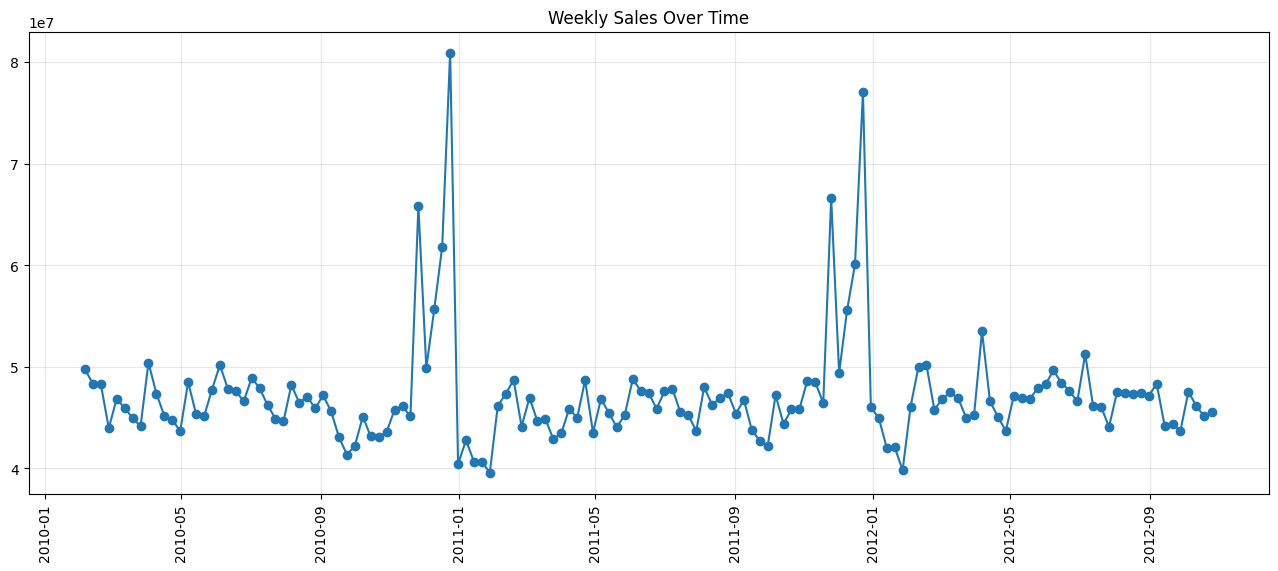

In [597]:
import matplotlib.pyplot as plt

# Sum weekly sales per date (all stores combined)
weekly_sales_sum = df.groupby('date')['weekly_sales'].sum()

plt.figure(figsize=(16,6))
plt.plot(weekly_sales_sum.index, weekly_sales_sum.values, marker='o')
plt.xticks(rotation=90)
plt.grid(alpha=0.3)
plt.title("Weekly Sales Over Time")
plt.show()

In [598]:
numerical_cols=[i for i in df.columns if df[i].dtypes!='O']
type(numerical_cols)

list

In [599]:
numerical_cols.remove('store')

In [600]:
numerical_cols.remove('date')

In [601]:
numerical_cols

['weekly_sales', 'temperature', 'fuel_price', 'cpi', 'unemployment', 'month']

In [602]:
df.head(2)

,store,date,weekly_sales,holiday_flag,temperature,fuel_price,cpi,unemployment,temp_group,month,month_name,fuel_group
0,1,2010-02-05,1643690.90,no,42.31,2.572,211.096358,8.106,40.00 to 50.00,2,February,2.4 to 2.8
1,1,2010-02-12,1641957.44,yes,38.51,2.548,211.242170,8.106,30.00 to 40.00,2,February,2.4 to 2.8


In [603]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   store         6435 non-null   int64         
 1   date          6435 non-null   datetime64[ns]
 2   weekly_sales  6435 non-null   float64       
 3   holiday_flag  6435 non-null   object        
 4   temperature   6435 non-null   float64       
 5   fuel_price    6435 non-null   float64       
 6   cpi           6435 non-null   float64       
 7   unemployment  6435 non-null   float64       
 8   temp_group    6435 non-null   object        
 9   month         6435 non-null   int32         
 10  month_name    6435 non-null   object        
 11  fuel_group    6435 non-null   object        
dtypes: datetime64[ns](1), float64(5), int32(1), int64(1), object(4)
memory usage: 578.3+ KB


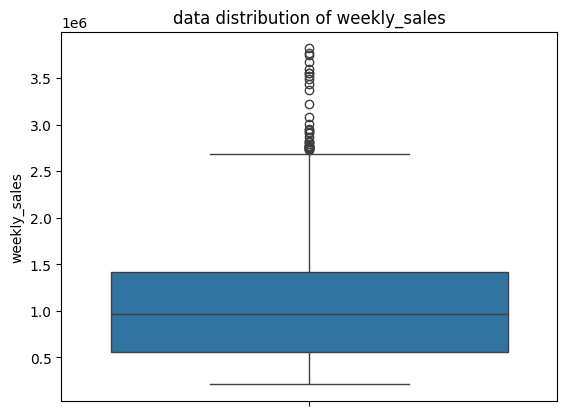

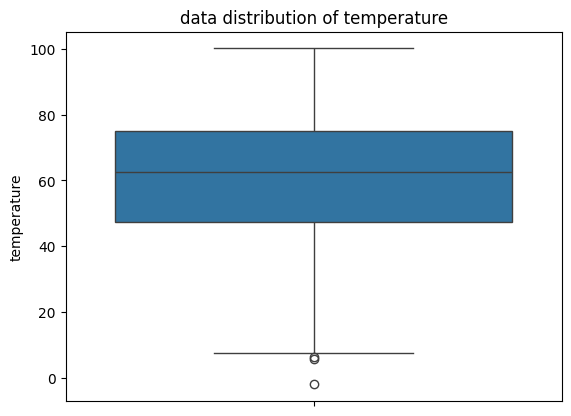

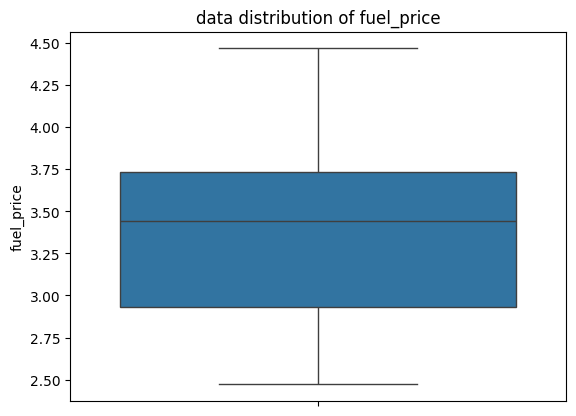

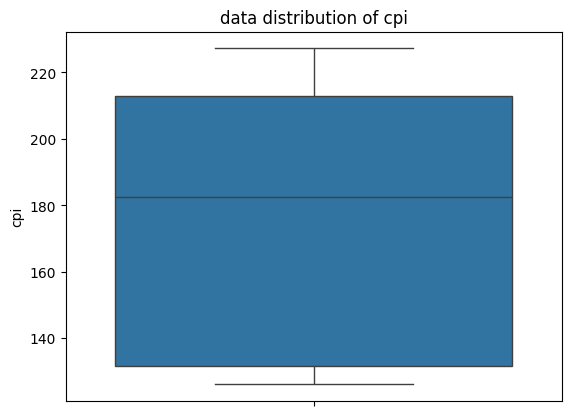

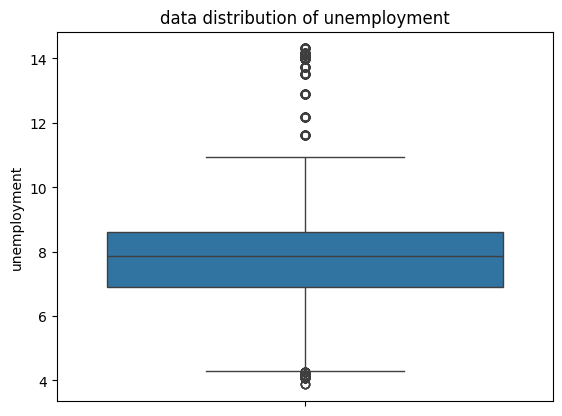

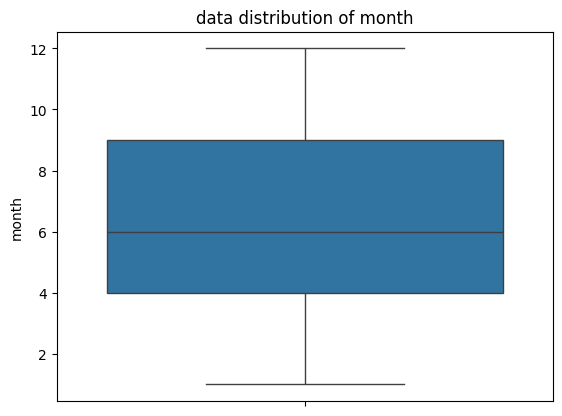

In [604]:
# box plot for all the numerical columns

for i in numerical_cols:
    sns.boxplot(df[i])
    plt.title(f"data distribution of {i}")
    plt.show()

In [605]:
# correlation between weekly sales and other features

df.corr(numeric_only=True)['weekly_sales']

store          -0.335332
weekly_sales    1.000000
temperature    -0.063810
fuel_price      0.009464
cpi            -0.072634
unemployment   -0.106176
month           0.076143
Name: weekly_sales, dtype: float64

In [606]:
df.corr(numeric_only=True)

,store,weekly_sales,temperature,fuel_price,cpi,unemployment,month
store,1.000000e+00,-0.335332,-0.022659,0.060023,-0.209492,0.223531,2.910676e-15
weekly_sales,-3.353320e-01,1.000000,-0.063810,0.009464,-0.072634,-0.106176,7.614332e-02
temperature,-2.265908e-02,-0.063810,1.000000,0.144982,0.176888,0.101158,2.358618e-01
fuel_price,6.002295e-02,0.009464,0.144982,1.000000,-0.170642,-0.034684,-4.215590e-02
cpi,-2.094919e-01,-0.072634,0.176888,-0.170642,1.000000,-0.302020,4.979672e-03
unemployment,2.235313e-01,-0.106176,0.101158,-0.034684,-0.302020,1.000000,-1.274559e-02
month,2.910676e-15,0.076143,0.235862,-0.042156,0.004980,-0.012746,1.000000e+00


<Axes: >

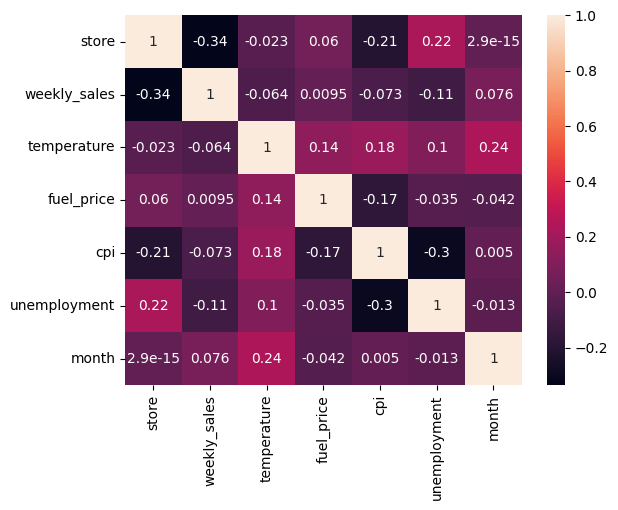

In [607]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

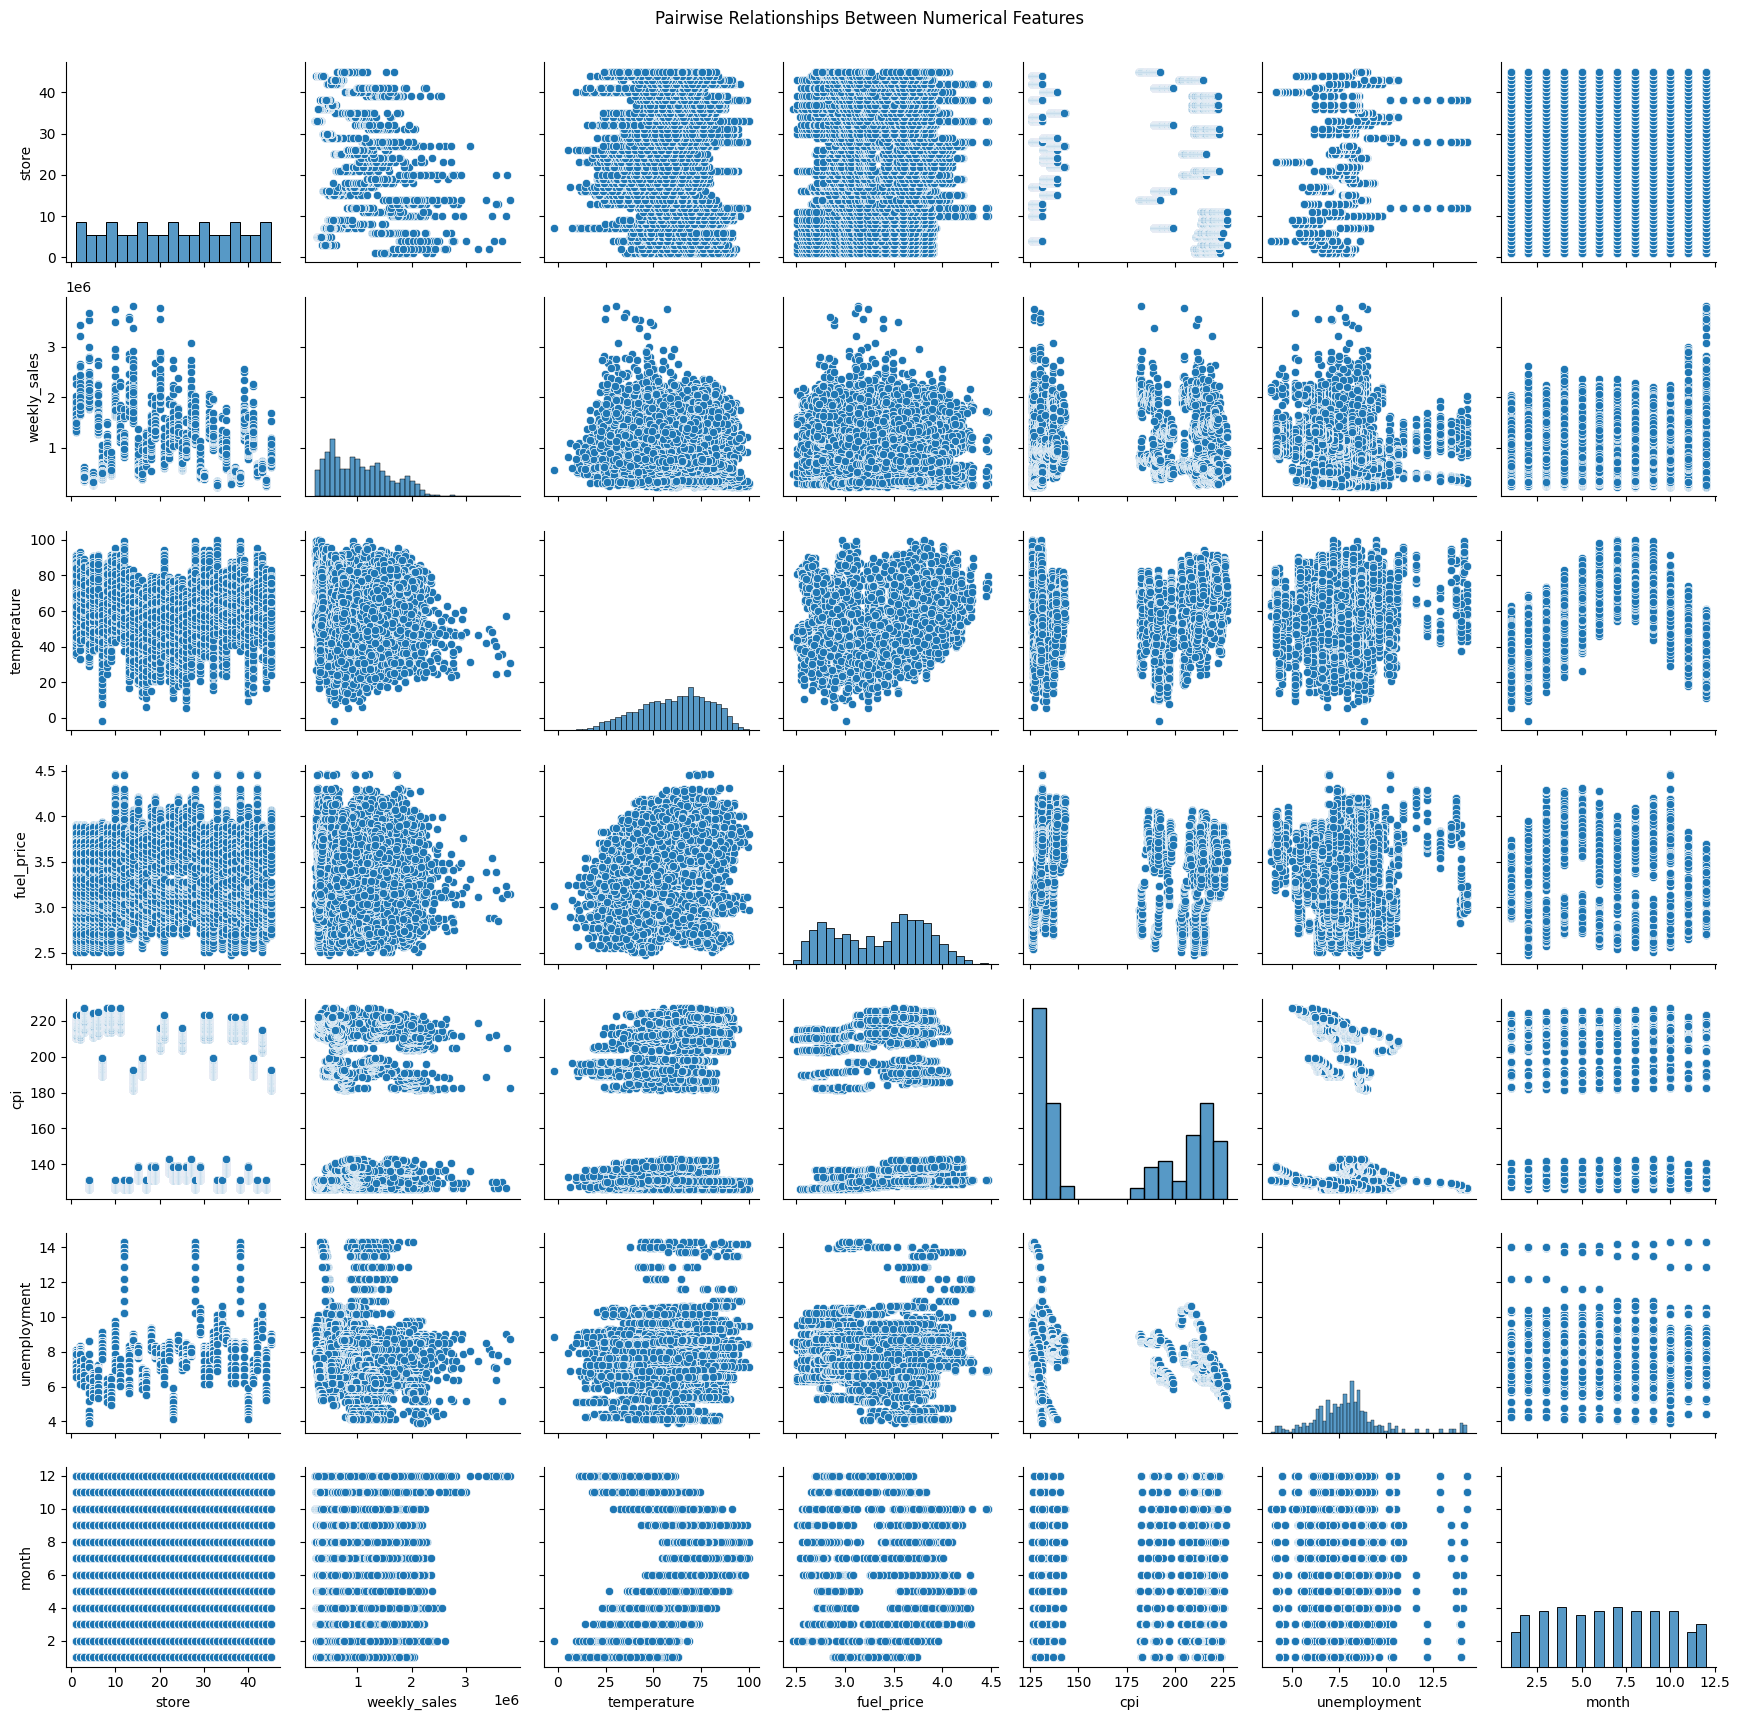

In [608]:

pair_plot = sns.pairplot(df)

pair_plot.fig.suptitle("Pairwise Relationships Between Numerical Features")

pair_plot.fig.tight_layout()
pair_plot.fig.subplots_adjust(top=0.95)  # Leave space for the title

plt.show()

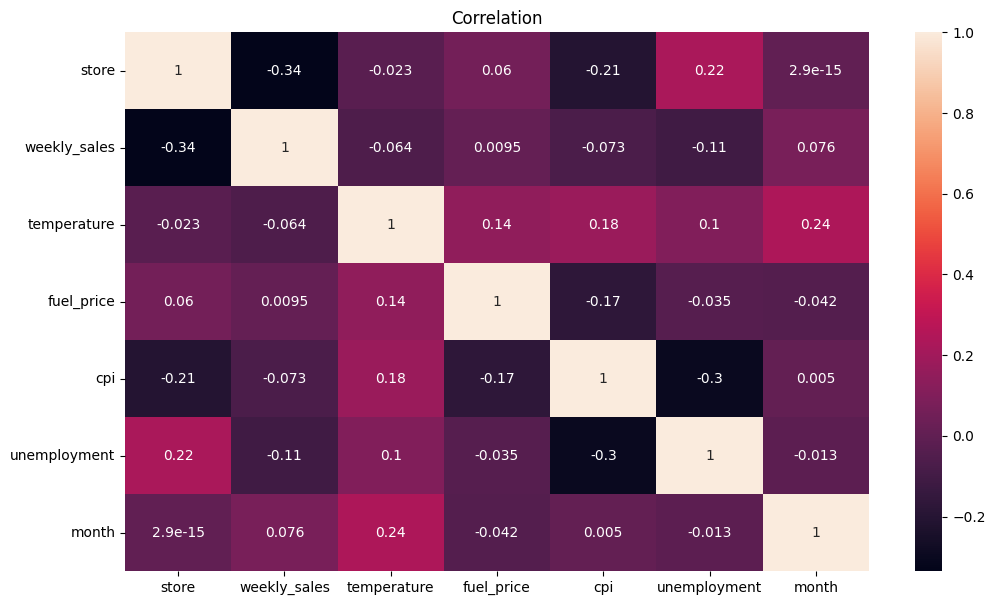

In [609]:
plt.figure(figsize=(12,7))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.title("Correlation")
plt.show()

 - weekly sales vs store has -0.34 co-relation moderate negative realtion it means as store number increases sales decrese slightly and when store number decreases sales increases slightly
 - weekly sales vs temp has -0.064 means very weak relation betweeen these two (no strong relation) it means as temp increases weekly sales decreses slightly and when temp decreases weekly sales increases slightly
 - weekly_sales vs fuel_price has 0.0095 means no relation changes in fuel price increase or decrease sales
 - weekly_sales vs cpi has -0.073 means very weak relation between this two
 - weekly_sales vs unemployemnt aslo dont have any strong relation
 - weelly_Sales vs month has 0.076 means Very weak positive relation

so we can conclude there is no strong relation between weekly sales and other features


In [610]:
numerical_cols

['weekly_sales', 'temperature', 'fuel_price', 'cpi', 'unemployment', 'month']

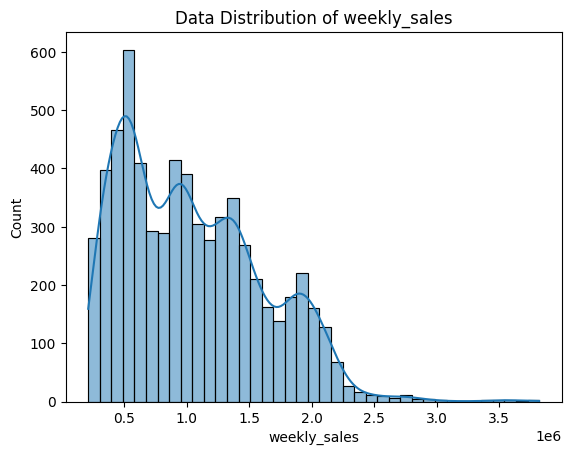

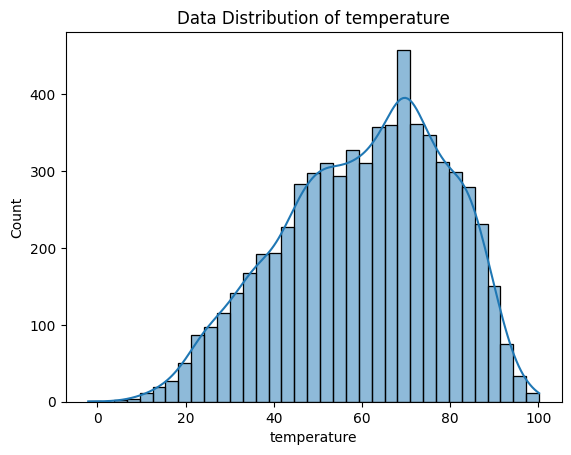

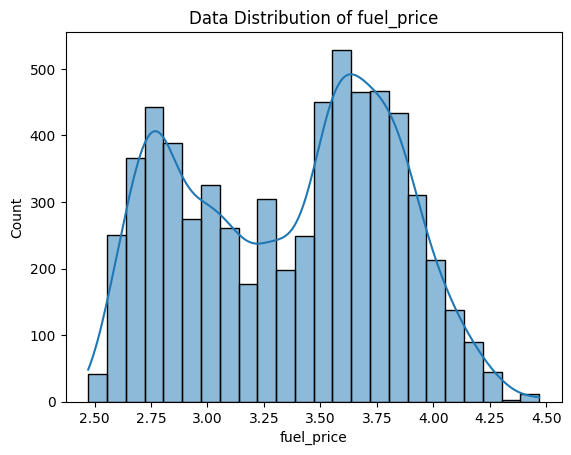

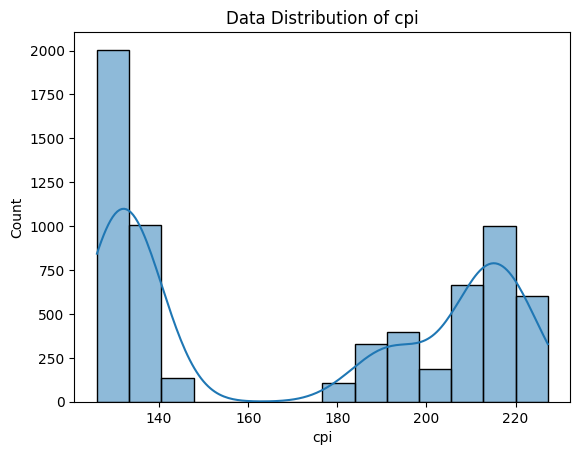

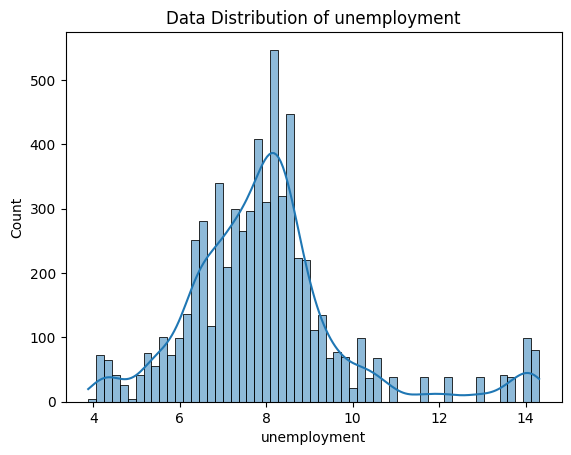

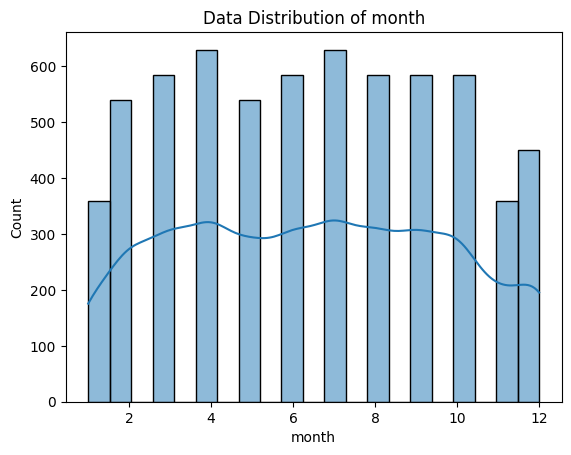

In [611]:
for i in numerical_cols:
    sns.histplot(df[i], kde=True)
    plt.title(f"Data Distribution of {i}")
    plt.show()

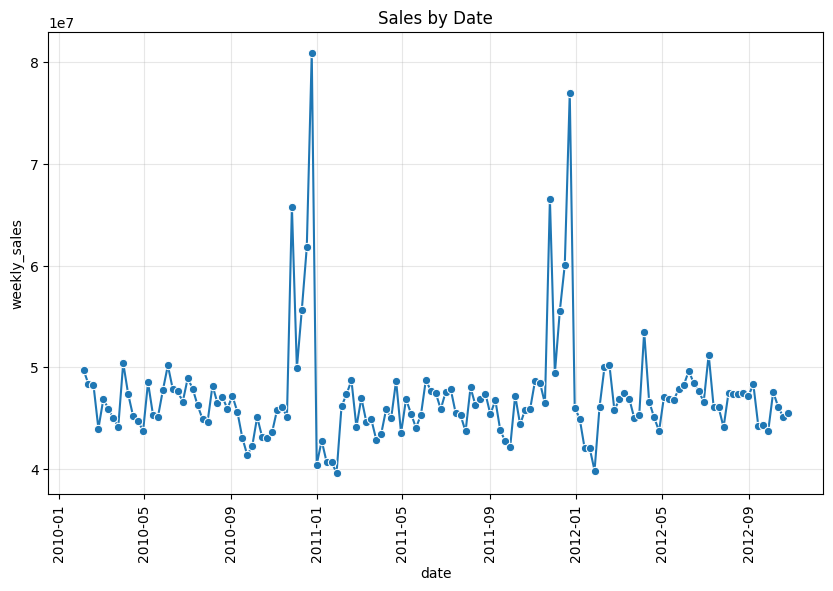

In [612]:
plt.figure(figsize=(10,6))
gb11=gb1.sort_values(by='date',ascending=True)
sns.lineplot(data=gb11,x='date',y='weekly_sales',marker='o')
plt.title("Sales by Date")
plt.xticks(rotation=90)
plt.grid(alpha=0.3)
plt.show()


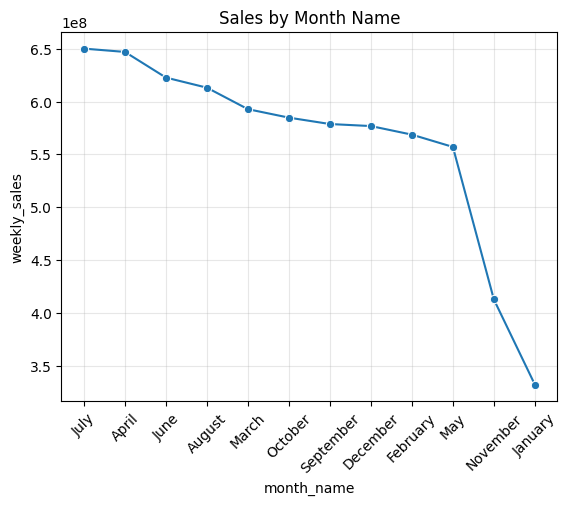

In [613]:
sns.lineplot(data=gb3,x='month_name',y='weekly_sales',marker='o')
plt.xticks(rotation=45)
plt.title("Sales by Month Name")
plt.grid(alpha=0.3)
plt.show()

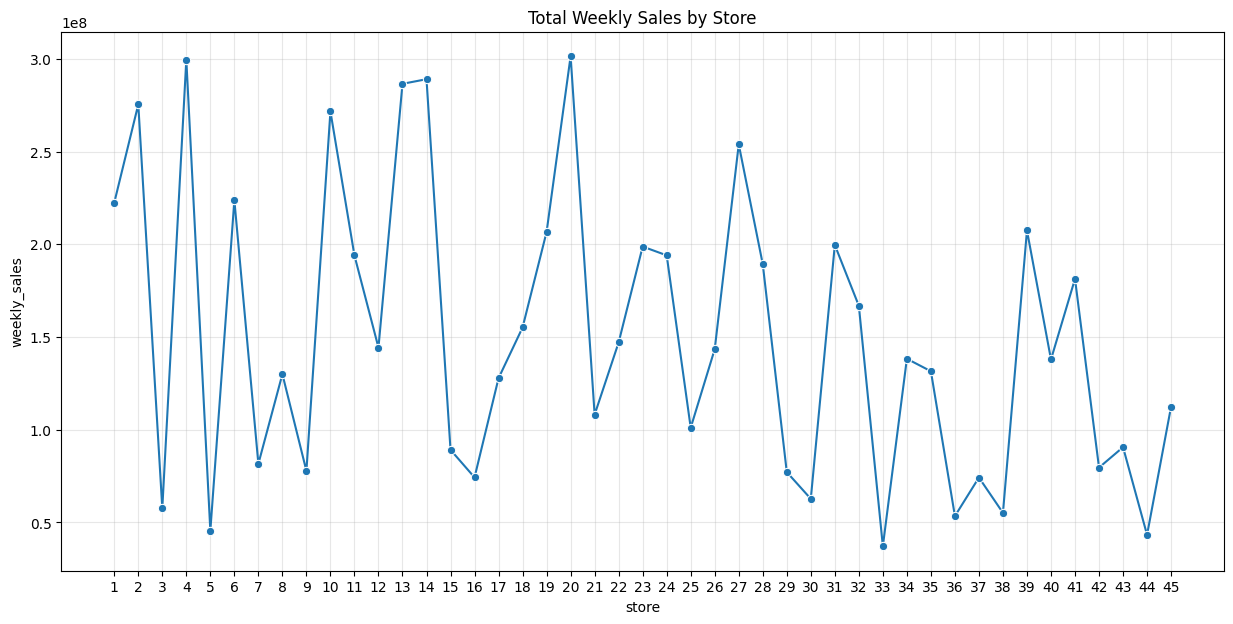

In [614]:
plt.figure(figsize=(15,7))
gb6=df.groupby('store')['weekly_sales'].sum().reset_index()
sns.lineplot(data=gb6,x='store',y='weekly_sales',marker='o')
plt.title("Total Weekly Sales by Store")
plt.xticks(gb6['store'])
plt.grid(alpha=0.3)
plt.show()

#### Feature Engineering

In [615]:
# store,temp,cpi,unemployment,month these are the columns to be considered for training model

In [616]:
df['year']=df['date'].dt.year


In [617]:
#encodign
    
# no :0
# yes : 1

df['holiday_flag']=df['holiday_flag'].map({"no":0,"yes":1})

In [618]:
df['lag1']=df['weekly_sales'].shift(1)

In [619]:
df.head(2)

,store,date,weekly_sales,holiday_flag,temperature,fuel_price,cpi,unemployment,temp_group,month,month_name,fuel_group,year,lag1
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,40.00 to 50.00,2,February,2.4 to 2.8,2010,NaN
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,30.00 to 40.00,2,February,2.4 to 2.8,2010,1643690.9


In [620]:
df.shape

(6435, 14)

In [621]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   store         6435 non-null   int64         
 1   date          6435 non-null   datetime64[ns]
 2   weekly_sales  6435 non-null   float64       
 3   holiday_flag  6435 non-null   int64         
 4   temperature   6435 non-null   float64       
 5   fuel_price    6435 non-null   float64       
 6   cpi           6435 non-null   float64       
 7   unemployment  6435 non-null   float64       
 8   temp_group    6435 non-null   object        
 9   month         6435 non-null   int32         
 10  month_name    6435 non-null   object        
 11  fuel_group    6435 non-null   object        
 12  year          6435 non-null   int32         
 13  lag1          6434 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int32(2), int64(2), object(3)
memory usage: 653.7+ KB


In [622]:
df.dropna(inplace=True)

In [623]:
X_features=['store','holiday_flag','temperature','cpi','unemployment','month','year','lag1']

In [624]:
X=df[X_features]
y=df['weekly_sales']

In [625]:
X

,store,holiday_flag,temperature,cpi,unemployment,month,year,lag1
1,1,1,38.51,211.242170,8.106,2,2010,1643690.90
2,1,0,39.93,211.289143,8.106,2,2010,1641957.44
3,1,0,46.63,211.319643,8.106,2,2010,1611968.17
4,1,0,46.50,211.350143,8.106,3,2010,1409727.59
5,1,0,57.79,211.380643,8.106,3,2010,1554806.68
...,...,...,...,...,...,...,...,...
6430,45,0,64.88,192.013558,8.684,9,2012,723086.20
6431,45,0,64.89,192.170412,8.667,10,2012,713173.95
6432,45,0,54.47,192.327265,8.667,10,2012,733455.07
6433,45,0,56.47,192.330854,8.667,10,2012,734464.36


In [626]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6434 entries, 1 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   store         6434 non-null   int64  
 1   holiday_flag  6434 non-null   int64  
 2   temperature   6434 non-null   float64
 3   cpi           6434 non-null   float64
 4   unemployment  6434 non-null   float64
 5   month         6434 non-null   int32  
 6   year          6434 non-null   int32  
 7   lag1          6434 non-null   float64
dtypes: float64(4), int32(2), int64(2)
memory usage: 402.1 KB


In [627]:
X.shape

(6434, 8)

#### Train Test Split

In [628]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [629]:
X_train.shape,X_test.shape

((4825, 8), (1609, 8))

In [630]:

from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()


In [631]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

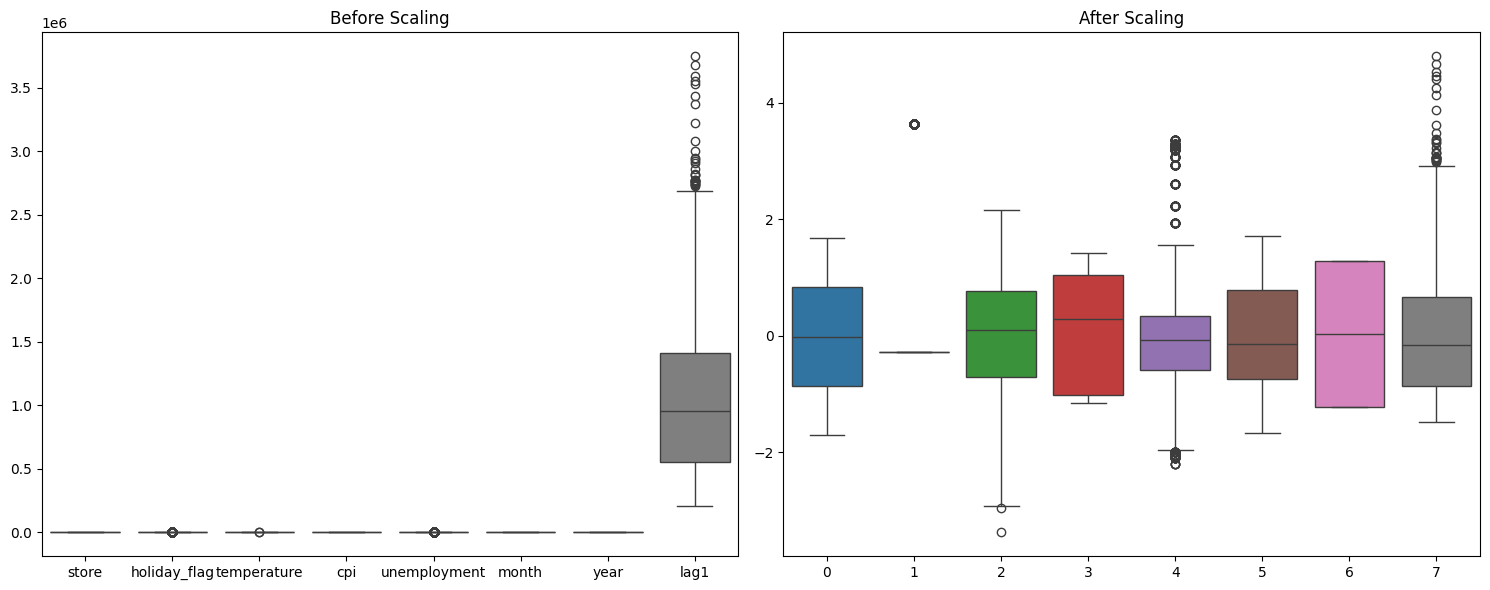

In [632]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
sns.boxplot(X_train)
plt.title("Before Scaling")

plt.subplot(1,2,2)
sns.boxplot(X_train_scaled)
plt.title("After Scaling")

plt.tight_layout()
plt.show()

In [633]:
X_train_scaled

array([[ 1.60016476, -0.27489714, -1.75913864, ...,  1.71409655,
         0.03219316, -1.30918441],
       [ 0.2913075 , -0.27489714,  0.24861491, ...,  0.7890519 ,
         1.28487069,  0.91468727],
       [-1.32551617, -0.27489714, -0.49555919, ...,  1.71409655,
         0.03219316,  2.14327199],
       ...,
       [ 1.06122354, -0.27489714,  1.47915607, ...,  0.48070369,
         0.03219316, -0.94275834],
       [ 1.13821514, -0.27489714, -0.53618004, ..., -1.67773383,
         1.28487069, -1.24110025],
       [-1.24852456, -0.27489714, -1.9183724 , ..., -1.36938561,
        -1.22048436, -0.94990442]])

#### Model Selection

In [634]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor


In [635]:
models={
    "LinearRegression":LinearRegression(),
    "RandomForestRegressor":RandomForestRegressor(),
    "GradientBoostingRegressor":GradientBoostingRegressor(),
    "AdaBoostRegressor":AdaBoostRegressor(),
    "DecisionTreeRegressor":DecisionTreeRegressor(),
    "KNeighborsRegressor":KNeighborsRegressor()
}

In [636]:
models

{'LinearRegression': LinearRegression(),
 'RandomForestRegressor': RandomForestRegressor(),
 'GradientBoostingRegressor': GradientBoostingRegressor(),
 'AdaBoostRegressor': AdaBoostRegressor(),
 'DecisionTreeRegressor': DecisionTreeRegressor(),
 'KNeighborsRegressor': KNeighborsRegressor()}

In [637]:
models.items()

dict_items([('LinearRegression', LinearRegression()), ('RandomForestRegressor', RandomForestRegressor()), ('GradientBoostingRegressor', GradientBoostingRegressor()), ('AdaBoostRegressor', AdaBoostRegressor()), ('DecisionTreeRegressor', DecisionTreeRegressor()), ('KNeighborsRegressor', KNeighborsRegressor())])

In [638]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

#### Model Training

In [639]:
score={}
for name,model in models.items():
    print(f"\n{name} training..\n")

    model.fit(X_train_scaled,y_train)

    y_train_pred=model.predict(X_train_scaled)
    y_test_pred=model.predict(X_test_scaled)

    print("evaluation metrics of train data")
    print("Mean Absolute Error",mean_absolute_error(y_train,y_train_pred))
    print("Mean Squared Error",mean_squared_error(y_train,y_train_pred))
    print("R2 score",r2_score(y_train,y_train_pred))
    print()
    print("evaluation metrics of test data")
    print("Mean Absolute Error",mean_absolute_error(y_test,y_test_pred))
    print("Mean Squared Error",mean_squared_error(y_test,y_test_pred))
    print("R2 score",r2_score(y_test,y_test_pred))

    score[name]=r2_score(y_test,y_test_pred)
    print("-"*40)
    print()


LinearRegression training..

evaluation metrics of train data
Mean Absolute Error 92121.4835915679
Mean Squared Error 32933606904.938847
R2 score 0.8960663463951775

evaluation metrics of test data
Mean Absolute Error 98655.63881942126
Mean Squared Error 35666734194.771065
R2 score 0.8894977598229287
----------------------------------------


RandomForestRegressor training..

evaluation metrics of train data
Mean Absolute Error 28424.948627150257
Mean Squared Error 3033514365.3787613
R2 score 0.990426671692336

evaluation metrics of test data
Mean Absolute Error 79799.10823903045
Mean Squared Error 22307984121.90824
R2 score 0.9308856761080527
----------------------------------------


GradientBoostingRegressor training..

evaluation metrics of train data
Mean Absolute Error 68520.04529766766
Mean Squared Error 13829309280.702435
R2 score 0.9563567196109657

evaluation metrics of test data
Mean Absolute Error 78836.76451163764
Mean Squared Error 19391750696.589855
R2 score 0.939920714

In [640]:
list(score.items())

[('LinearRegression', 0.8894977598229287),
 ('RandomForestRegressor', 0.9308856761080527),
 ('GradientBoostingRegressor', 0.9399207148816385),
 ('AdaBoostRegressor', 0.7953843058455592),
 ('DecisionTreeRegressor', 0.8892542699263937),
 ('KNeighborsRegressor', 0.9213901439997484)]

In [641]:
df_scores=pd.DataFrame(list(score.items()), columns=['Model', 'R2 Score'])
df_scores.sort_values(by='R2 Score',ascending=False)


,Model,R2 Score
2,GradientBoostingRegressor,0.939921
1,RandomForestRegressor,0.930886
5,KNeighborsRegressor,0.921390
0,LinearRegression,0.889498
4,DecisionTreeRegressor,0.889254
3,AdaBoostRegressor,0.795384


we are selecting GradientBoostingRegressor,RandomForestRegressor and KNeighborsRegressor models because there r2_score is highest

#### Hyperparameter Tuning

In [642]:
params={
    "GradientBoostingRegressor":{
        "n_estimators":[10,20,50,100],
        "learning_rate":[0.1,0.01,0.001],
        "max_depth":[1,2,15,5,10],
        "subsample":[0.5,0.7,0.8,0.2]
    },
    "RandomForestRegressor":{
        "n_estimators":[10,20,50,100,120,300],
        "max_depth":[2,5,10,15,12,20],
        "min_samples_split":[2,3,5],
        "min_samples_split":[1,2,3]
    },
    "KNeighborsRegressor":{
        "n_neighbors":[3,5,7,15,21],
        "weights":['uniform','distance']
    }
}

In [643]:
models={
    "RandomForestRegressor":RandomForestRegressor(),
    "GradientBoostingRegressor":GradientBoostingRegressor(),
    "KNeighborsRegressor":KNeighborsRegressor(),
}

In [644]:
from sklearn.model_selection import RandomizedSearchCV


In [645]:
params['GradientBoostingRegressor']

{'n_estimators': [10, 20, 50, 100],
 'learning_rate': [0.1, 0.01, 0.001],
 'max_depth': [1, 2, 15, 5, 10],
 'subsample': [0.5, 0.7, 0.8, 0.2]}

In [646]:
import warnings
warnings.filterwarnings('ignore')

In [647]:
best_models={}
for name,model in models.items():
    print(f"\n{name} training..\n")

    rs=RandomizedSearchCV(estimator=model,param_distributions=params[name],cv=5,n_iter=20,scoring='r2',n_jobs=1)
    rs.fit(X_train_scaled,y_train)

    y_train_pred=rs.predict(X_train_scaled)
    y_test_pred=rs.predict(X_test_scaled)

    print("evaluation metrics of train data")
    print("Mean Absolute Error",mean_absolute_error(y_train,y_train_pred))
    print("Mean Squared Error",mean_squared_error(y_train,y_train_pred))
    print("R2 score",r2_score(y_train,y_train_pred))
    print()
    print("evaluation metrics of test data")
    print("Mean Absolute Error",mean_absolute_error(y_test,y_test_pred))
    print("Mean Squared Error",mean_squared_error(y_test,y_test_pred))
    print("R2 score",r2_score(y_test,y_test_pred))

    best_models[name]=rs.best_estimator_
    print("best params:",rs.best_params_)
    print("best cv score:",rs.best_score_)
    print("-"*40)
    print()


RandomForestRegressor training..

evaluation metrics of train data
Mean Absolute Error 29523.932687173125
Mean Squared Error 3258509763.563374
R2 score 0.9897166190751083

evaluation metrics of test data
Mean Absolute Error 80357.80311523774
Mean Squared Error 22873889850.099216
R2 score 0.9291323938940813
best params: {'n_estimators': 120, 'min_samples_split': 2, 'max_depth': 20}
best cv score: 0.9261983498288678
----------------------------------------


GradientBoostingRegressor training..

evaluation metrics of train data
Mean Absolute Error 46902.2007463144
Mean Squared Error 4547785251.065915
R2 score 0.9856478539287319

evaluation metrics of test data
Mean Absolute Error 82833.78877419946
Mean Squared Error 21976429695.231033
R2 score 0.931912893982512
best params: {'subsample': 0.2, 'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.1}
best cv score: 0.9219099978334541
----------------------------------------


KNeighborsRegressor training..

evaluation metrics of train 

GradientBoostingRegressor has highest score 

In [690]:
rf = RandomForestRegressor(n_estimators=120, min_samples_split=2,max_depth=20, random_state=42)
rf.fit(X_train_scaled, y_train)

# predict on correct test set
y_pred = rf.predict(X_test_scaled)

# verify shapes match now
print("y_test shape:", y_test.shape)    # should be (1609,)
print("y_pred shape:", y_pred.shape)    # should be (1609,)
print("y_test range:", y_test.min(), "to", y_test.max())
print("y_pred range:", y_pred.min(), "to", y_pred.max())

y_test shape: (1609,)
y_pred shape: (1609,)
y_test range: 209986.25 to 3224369.8
y_pred range: 236777.24743750037 to 2892695.6803333266


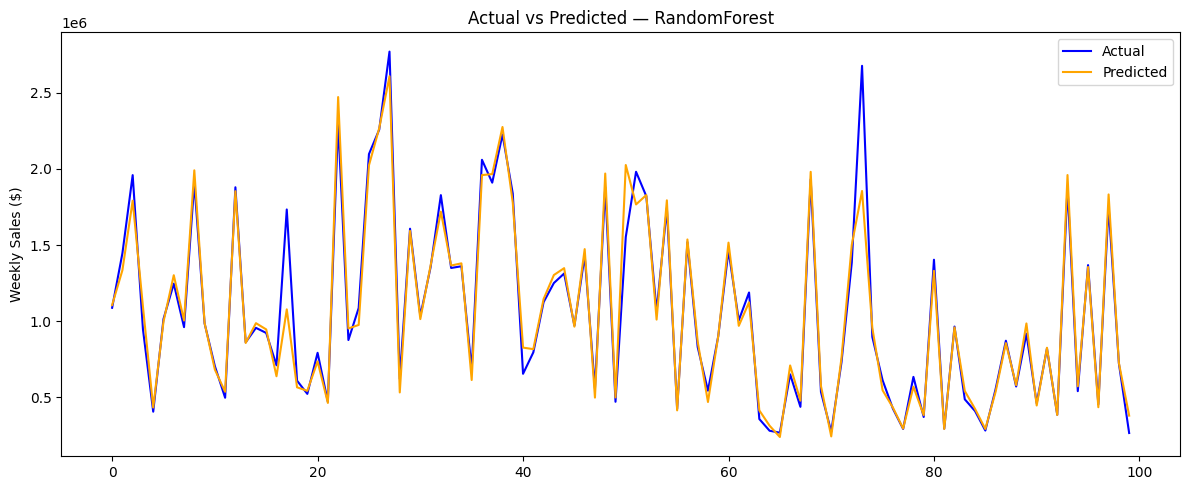

In [691]:
y_test_plot = y_test.reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.plot(y_test_plot[:100], label='Actual', color='blue')
plt.plot(y_pred[:100], label='Predicted', color='orange')
plt.legend()
plt.title("Actual vs Predicted — RandomForest")
plt.ylabel("Weekly Sales ($)")
plt.tight_layout()
plt.show()

In [692]:
print("evaluation metrics of test data")
print("Mean Absolute Error",mean_absolute_error(y_test,y_pred))
print("Mean Squared Error",mean_squared_error(y_test,y_pred))
print("R2 score",r2_score(y_test,y_pred))

evaluation metrics of test data
Mean Absolute Error 79999.94402818264
Mean Squared Error 22806217823.3944
R2 score 0.929342054540536


In [693]:
store = 5
holiday_flag = 1
temperature = 28.5
cpi = 220.3
unemployment = 7.2
month = 12
year = 2012
lag1 = 1500000

In [694]:
df.head(2)

,store,date,weekly_sales,holiday_flag,temperature,fuel_price,cpi,unemployment,temp_group,month,month_name,fuel_group,year,lag1
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,30.00 to 40.00,2,February,2.4 to 2.8,2010,1643690.90
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,30.00 to 40.00,2,February,2.4 to 2.8,2010,1641957.44


#### Prediction on New Data

In [695]:
new_df=pd.DataFrame({
    "store" : [1],
    "holiday_flag":[0],
    "temperature":[39.93],
    "cpi":[211.28],
    "unemployment":[8.10],
    "month":[2],
    "year":[2010],
    "lag1":[1641957.44]
})
new_df

,store,holiday_flag,temperature,cpi,unemployment,month,year,lag1
0,1,0,39.93,211.28,8.1,2,2010,1641957.44


In [696]:
new_df_scaled=scaler.transform(new_df)
new_df_scaled

array([[-1.71047418, -0.27489714, -1.10487204,  1.01563647,  0.05356887,
        -1.36938561, -1.22048436,  1.0645887 ]])

In [697]:
rf

RandomForestRegressor(max_depth=20, n_estimators=120, random_state=42)

In [698]:
new_df_pred=rf.predict(new_df_scaled)
print("prediction:",new_df_pred[0])

prediction: 1618522.3614722204


In [699]:
import pickle

with open("RandomForestRegressor.pkl","wb") as f:
    pickle.dump(rf,f)

In [700]:
with open("scaler.pkl","wb")as f:
    pickle.dump(scaler,f)

In [659]:
X_train

,store,holiday_flag,temperature,cpi,unemployment,month,year,lag1
6246,44,0,27.85,129.898065,6.078,12,2011,304300.91
3856,27,0,64.92,142.765750,8.239,9,2012,1557485.75
810,6,0,51.18,220.293769,6.551,12,2011,2249811.55
1808,13,0,33.80,129.816710,6.392,11,2011,2036317.54
5954,42,0,68.57,129.805194,7.874,11,2011,515599.70
...,...,...,...,...,...,...,...,...
3773,27,0,33.05,137.376444,7.827,2,2011,1709365.19
5192,37,0,51.83,210.237249,8.476,12,2010,508213.14
5227,37,0,87.64,214.360270,8.177,8,2011,510787.46
5391,38,0,50.43,130.157516,12.187,1,2012,342667.35


In [701]:
df.head(2)

,store,date,weekly_sales,holiday_flag,temperature,fuel_price,cpi,unemployment,temp_group,month,month_name,fuel_group,year,lag1
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,30.00 to 40.00,2,February,2.4 to 2.8,2010,1643690.90
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,30.00 to 40.00,2,February,2.4 to 2.8,2010,1641957.44


#### Time Series Forecasting

##### ARIMA

In [702]:
df_grouped=df.groupby('date')['weekly_sales'].sum().reset_index()
df_grouped

,date,weekly_sales
0,2010-02-05,48107049.60
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30
...,...,...
138,2012-09-28,43734899.40
139,2012-10-05,47566639.31
140,2012-10-12,46128514.25
141,2012-10-19,45122410.57


In [703]:
df_grouped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          143 non-null    datetime64[ns]
 1   weekly_sales  143 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.4 KB


In [704]:
df_grouped.set_index('date',inplace=True)

In [705]:
df_grouped

,weekly_sales
date,
2010-02-05,48107049.60
2010-02-12,48336677.63
2010-02-19,48276993.78
2010-02-26,43968571.13
2010-03-05,46871470.30
...,...
2012-09-28,43734899.40
2012-10-05,47566639.31
2012-10-12,46128514.25


In [706]:
import plotly.express as px

px.line(df_grouped,x=df_grouped.index,y=df_grouped['weekly_sales'])

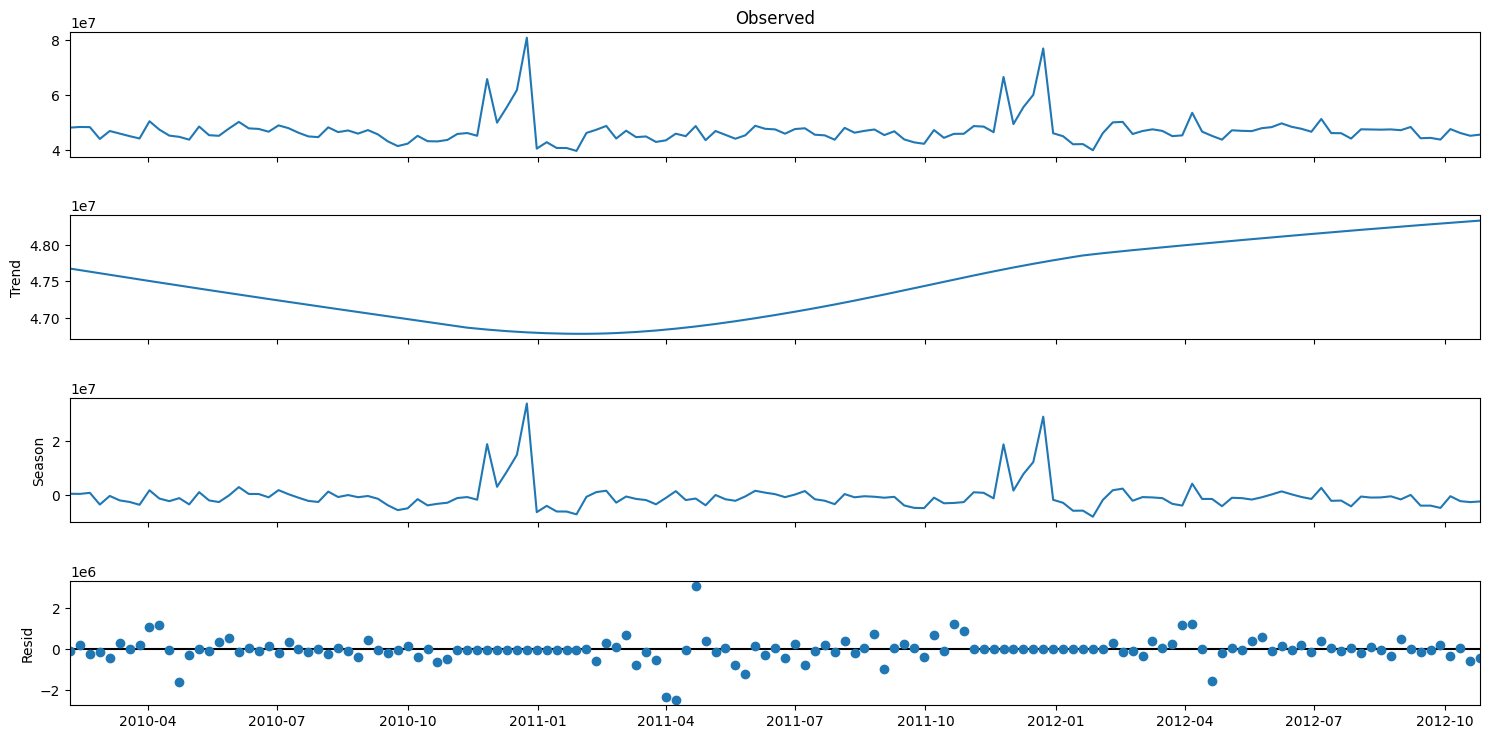

In [707]:
from statsmodels.tsa.seasonal import STL

stl=STL(df_grouped,seasonal=53) #53 because pattern is repeating after 1 year= 53 weeks if pattern were repeating weekly lets say at 2023-01-01 sales increases then 2023-01-8 sales increases and like thiss so onn then we use seasonal =7
# means if it were Daily data → yearly seasonality = 365
# Weekly data → yearly seasonality = 52
# Monthly data → yearly seasonality = 12

res=stl.fit()
fig=res.plot()
fig.set_size_inches(17,8)
plt.show()

In [708]:
from statsmodels.tsa.stattools import adfuller

In [709]:
# h0 : not stationary
# h1 : stationary

def adfuller_test(sales):
    result=adfuller(sales)
    labels=['ADF test statistics','p-value','lags used','no of observations used']

    for res,label in zip(result,labels):
        print(label + " : " + str(res))
    if result[1]<=0.05:
        print("\nreject null hypothesis i.e data is stationary")
    else:
        print("\naccept null hypothesis i.e data is non stationary")

In [710]:
adfuller_test(df_grouped['weekly_sales'])

ADF test statistics : -5.907152384859451
p-value : 2.691787886293493e-07
lags used : 4
no of observations used : 138

reject null hypothesis i.e data is stationary


as data is stationary we dont need to do differencing

In [711]:
import plotly.express as px

px.line(df_grouped,x=df_grouped.index,y=df_grouped['weekly_sales'])

In [712]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

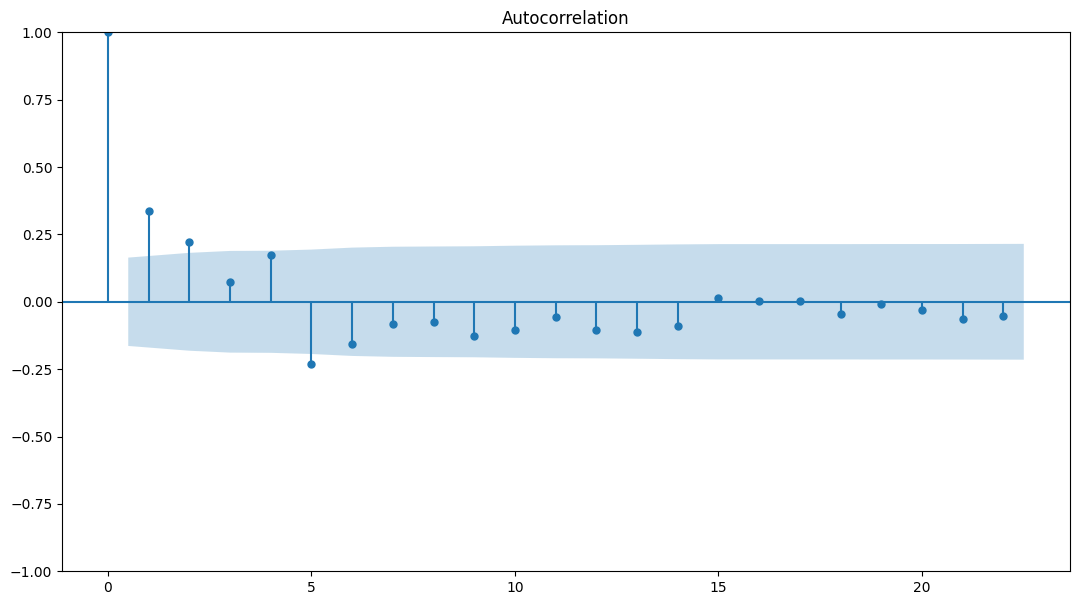

In [713]:
fig=plot_acf(df_grouped['weekly_sales'])
fig.set_size_inches(13,7)
plt.show()

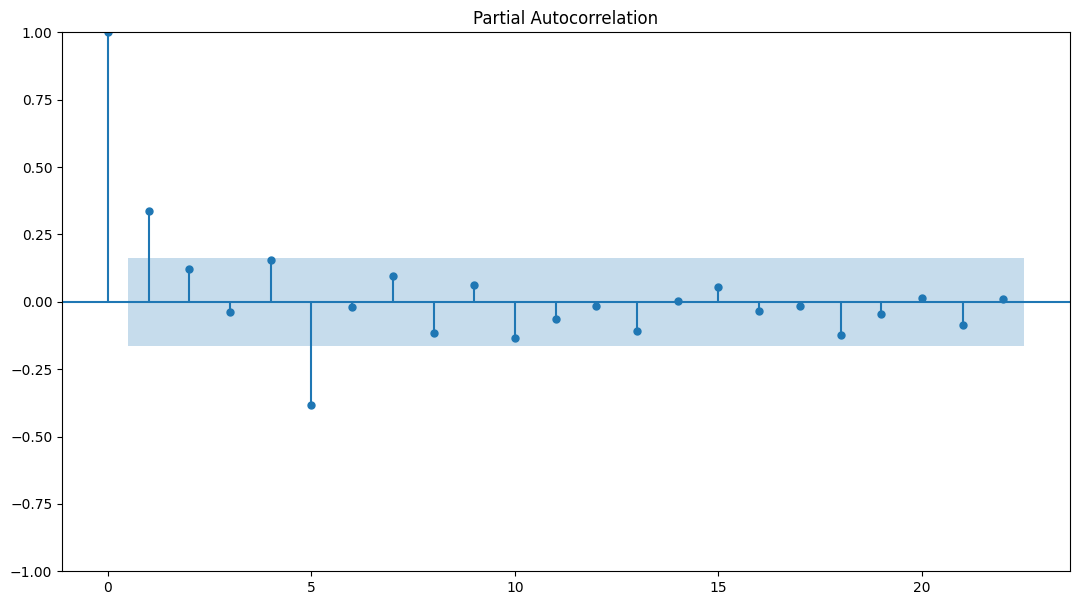

In [714]:
fig2=plot_pacf(df_grouped['weekly_sales'])
fig2.set_size_inches(13,7)
plt.show()

In [715]:
from pmdarima import auto_arima

auto_arima(df_grouped['weekly_sales'])

ARIMA(order=(2, 0, 0), scoring_args={}, suppress_warnings=True)

In [716]:
from pmdarima import auto_arima

model = auto_arima(
    df_grouped['weekly_sales'],
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    d=None,              # automatically find differencing
    seasonal=False,      # set True if seasonality present
    trace=True,          # shows steps
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=5462.696, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=5370.457, Time=0.15 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=4853.614, Time=0.27 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=4843.553, Time=0.14 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=inf, Time=0.30 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=4855.816, Time=0.36 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=inf, Time=0.58 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=0.15 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=0.48 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=4831.223, Time=0.07 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=4830.421, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=4834.427, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=4829.314, Time=0.04 s

In [717]:
from statsmodels.tsa.arima.model import ARIMA

model=ARIMA(df_grouped['weekly_sales'],order=(2,0,2))
model_fit=model.fit()

In [718]:
df_grouped.shape

(143, 1)

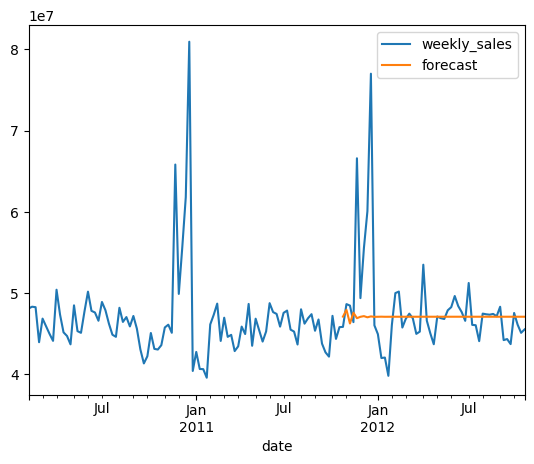

In [719]:
df_grouped['forecast']=model_fit.predict(start=90,end=143,dynamic=True)
df_grouped[['weekly_sales','forecast']].plot()
plt.show()

##### SARIMA

In [720]:
import statsmodels.api as sm

model=sm.tsa.statespace.SARIMAX(df_grouped['weekly_sales'],order=(2,0,2),seasonal_order=(2,0,2,52))
model_fit=model.fit()

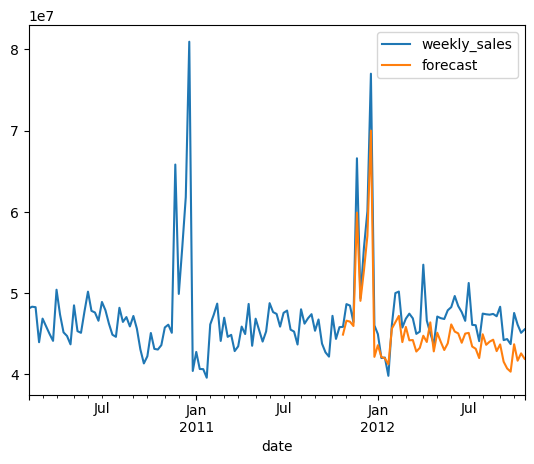

In [721]:
df_grouped['forecast']=model_fit.predict(start=90,end=143,dynamic=True)
df_grouped[['weekly_sales','forecast']].plot()
plt.show()

##### Prophet

In [722]:
from prophet import Prophet


In [723]:
df_prophet=df[['date','weekly_sales','holiday_flag']]
df_prophet

,date,weekly_sales,holiday_flag
1,2010-02-12,1641957.44,1
2,2010-02-19,1611968.17,0
3,2010-02-26,1409727.59,0
4,2010-03-05,1554806.68,0
5,2010-03-12,1439541.59,0
...,...,...,...
6430,2012-09-28,713173.95,0
6431,2012-10-05,733455.07,0
6432,2012-10-12,734464.36,0
6433,2012-10-19,718125.53,0


In [724]:
df_prophet.columns=['ds','y','holiday_flag']
df_prophet

,ds,y,holiday_flag
1,2010-02-12,1641957.44,1
2,2010-02-19,1611968.17,0
3,2010-02-26,1409727.59,0
4,2010-03-05,1554806.68,0
5,2010-03-12,1439541.59,0
...,...,...,...
6430,2012-09-28,713173.95,0
6431,2012-10-05,733455.07,0
6432,2012-10-12,734464.36,0
6433,2012-10-19,718125.53,0


In [725]:
df.groupby('date')['holiday_flag'].max() # returns max flag value out of all store 

date
2010-02-05    0
2010-02-12    1
2010-02-19    0
2010-02-26    0
2010-03-05    0
             ..
2012-09-28    0
2012-10-05    0
2012-10-12    0
2012-10-19    0
2012-10-26    0
Name: holiday_flag, Length: 143, dtype: int64

20:49:30 - cmdstanpy - INFO - Chain [1] start processing
20:49:30 - cmdstanpy - INFO - Chain [1] done processing


(143, 3)
          ds            y  holiday_flag
0 2010-02-05  48107049.60             0
1 2010-02-12  48336677.63             1
2 2010-02-19  48276993.78             0
3 2010-02-26  43968571.13             0
4 2010-03-05  46871470.30             0


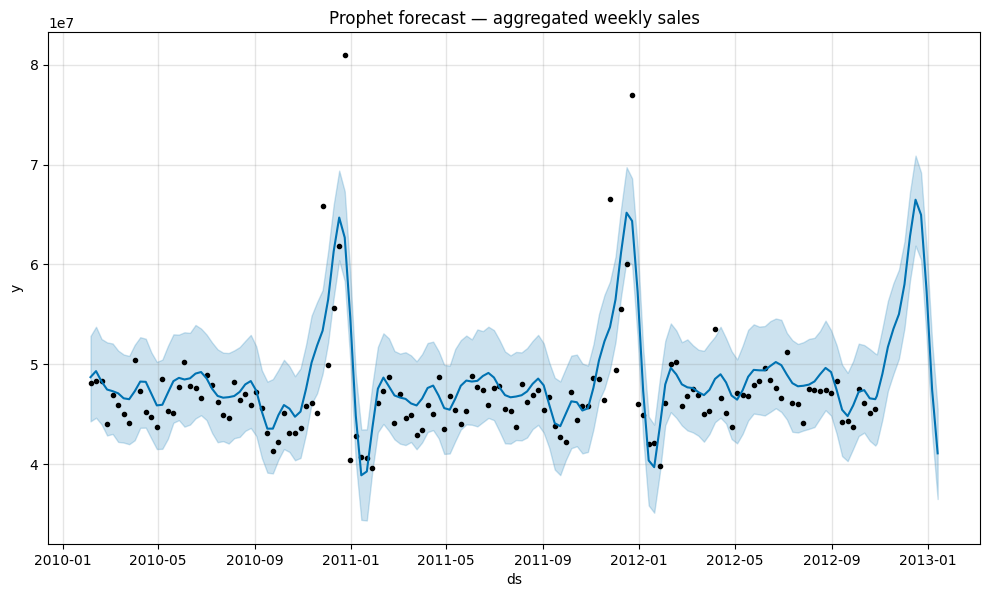

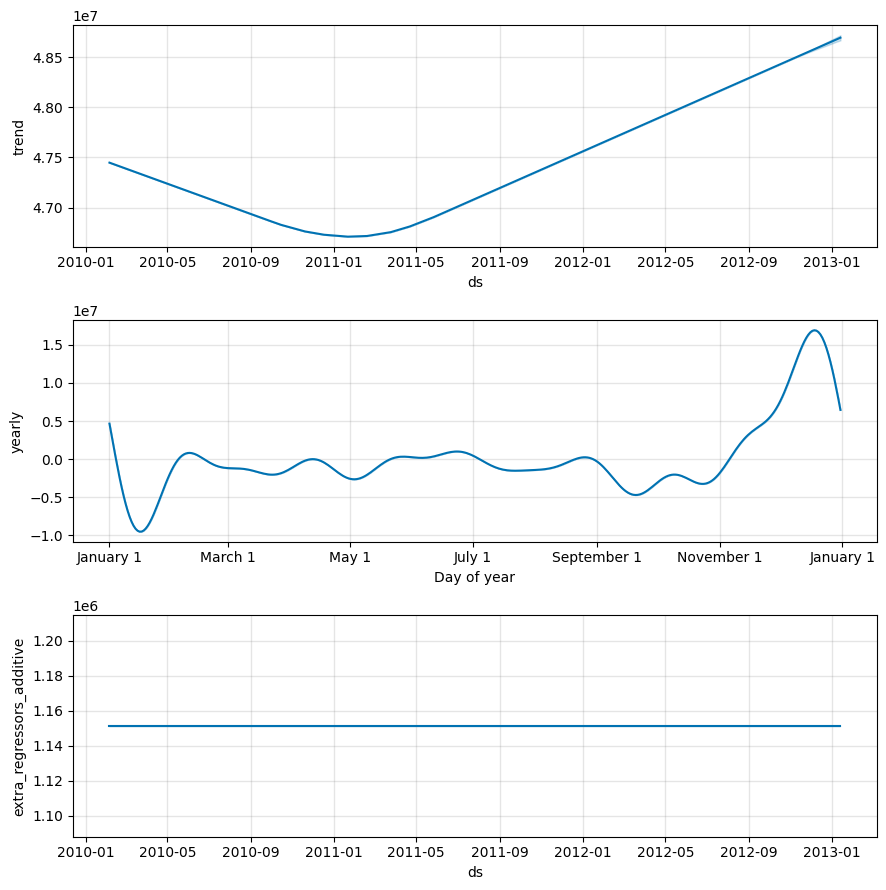

In [726]:
from prophet import Prophet
import pandas as pd

df_grouped = df.groupby('date')['weekly_sales'].sum().reset_index()


df_prophet = df_grouped.rename(columns={'date': 'ds', 'weekly_sales': 'y'}).copy() #rename


holiday_by_date = df.groupby('date')['holiday_flag'].max().reset_index()
df_prophet = df_prophet.merge(holiday_by_date, left_on='ds', right_on='date').drop('date', axis=1)

print(df_prophet.shape)   # should be (143, 3) — 143 weeks, not 6435 rows
print(df_prophet.head())  # check it looks right before fitting


m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    changepoint_prior_scale=0.3
)
m.add_regressor('holiday_flag')
m.fit(df_prophet)


future = m.make_future_dataframe(periods=12, freq='W') #12 weeks forecast
future['holiday_flag'] = 1  # no holidays in future weeks (adjust if needed)
forecast = m.predict(future)


m.plot(forecast)
plt.title('Prophet forecast — aggregated weekly sales')
plt.show()

m.plot_components(forecast)
plt.show()

In [727]:
from prophet.diagnostics import cross_validation, performance_metrics
df_cv = cross_validation(m, initial='365 days', period='90 days', horizon='90 days')
df_p = performance_metrics(df_cv)
print(df_p[['horizon','mae','mape','rmse']])

Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
  0%|          | 0/6 [00:00<?, ?it/s]20:49:31 - cmdstanpy - INFO - Chain [1] start processing
20:49:31 - cmdstanpy - INFO - Chain [1] done processing
 17%|█▋        | 1/6 [00:00<00:02,  1.90it/s]20:49:32 - cmdstanpy - INFO - Chain [1] start processing
20:49:32 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 2/6 [00:00<00:01,  2.51it/s]20:49:32 - cmdstanpy - INFO - Chain [1] start processing
20:49:32 - cmdstanpy - INFO - Chain [1] done processing
 50%|█████     | 3/6 [00:01<00:01,  2.27it/s]20:49:32 - cmdstanpy - INFO - Chain [1] start processing
20:49:32 - cmdstanpy - INFO - Chain [1] done processing
 67%|██████▋   | 4/6 [00:01<00:00,  2.94it/s]20:49:33 - cmdstanpy - INFO - Chain [1] start processing
20:49:33 - cmdstanpy - INFO - Chain [1] done processing
 83%|████████▎ | 5/6 [00:01<00:00,  3.46it/s]20:49:33 - cmdstanpy - INFO - Chain [1] start processing
20:49:33 - c

   horizon           mae      mape          rmse
0   8 days  1.839111e+06  0.038717  2.154487e+06
1   9 days  1.580582e+06  0.033251  1.878360e+06
2  10 days  1.116854e+06  0.023589  1.373440e+06
3  11 days  9.140963e+05  0.019332  1.068604e+06
4  12 days  9.183966e+05  0.019390  1.071085e+06
..     ...           ...       ...           ...
67 86 days  2.274981e+06  0.050893  2.645984e+06
68 87 days  2.176829e+06  0.050242  2.511688e+06
69 88 days  1.992244e+06  0.045602  2.309227e+06
70 89 days  2.194941e+06  0.050327  2.522799e+06
71 90 days  2.082257e+06  0.047889  2.494581e+06

[72 rows x 4 columns]


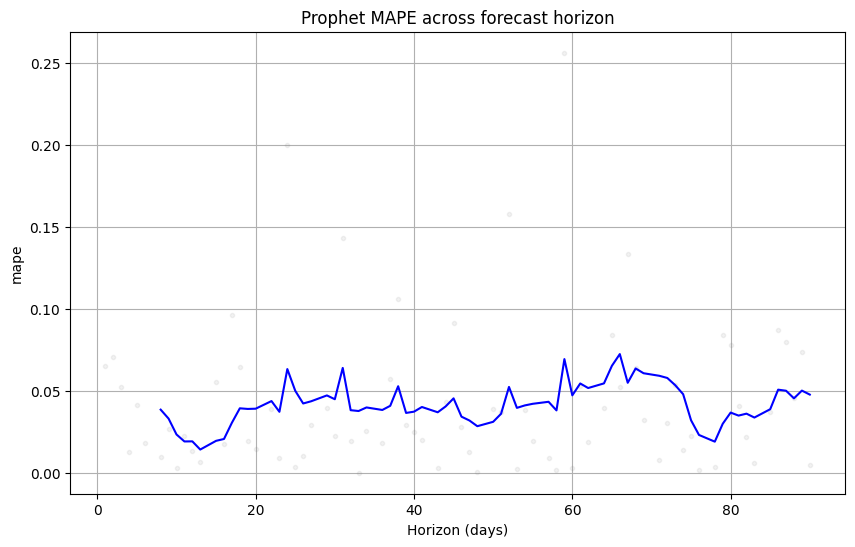

In [728]:
from prophet.plot import plot_cross_validation_metric

plot_cross_validation_metric(df_cv, metric='mape')
plt.title("Prophet MAPE across forecast horizon")
plt.show()

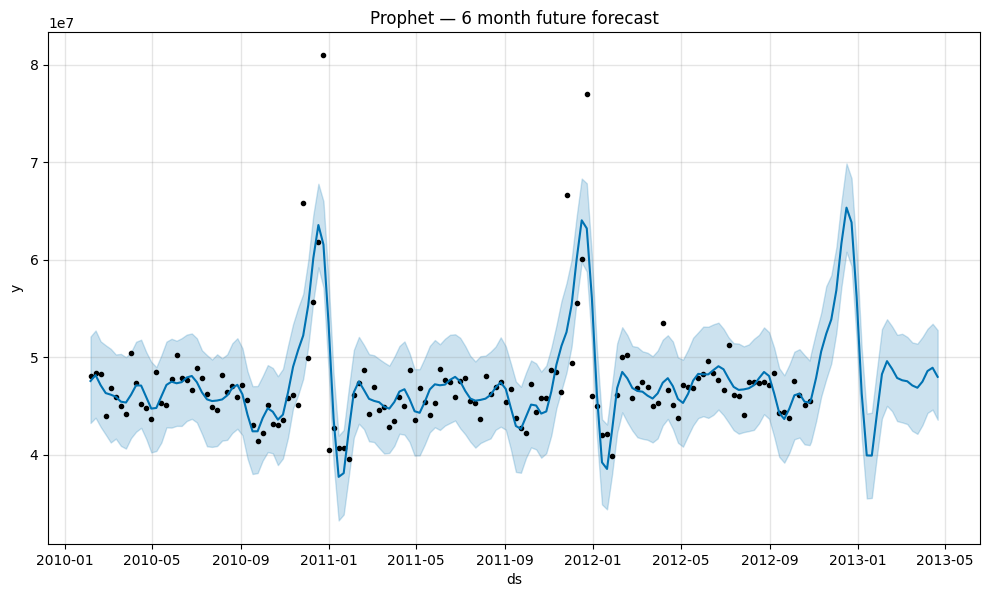

In [729]:
future = m.make_future_dataframe(periods=26, freq='W')  # 26 weeks = 6 months
future['holiday_flag'] = 0  # assume no holidays, change to 1 where needed

forecast = m.predict(future)

m.plot(forecast)
plt.title("Prophet — 6 month future forecast")
plt.show()

 - **RandomForest**  gave the best results
 - **ARIMA and SARIMA** did not perform well because they could not 
  use features like holidays, store number and previous week sales
 - **Prophet** handled the seasonal pattern and holiday spikes better 
  than ARIMA but still not as good as the ML models